In [45]:
# Code cell: imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV


In [46]:
# Code cell: load data
df = pd.read_csv(r"C:\Users\LENOVO\Documents\GitHub\ml-assessment-sumathi-srinivasan\data\q1_heart_disease.csv")

# Basic inspection
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())

# First five rows
df.head()


Shape: (800, 12)

Data types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


1. Data loading and inspection:
The dataset has rows representing patients and columns such as age, sex, chest_pain_type, resting_bp, cholesterol, and the target heart_disease. The missing value summary shows that some numeric columns (e.g., resting_bp, cholesterol) contain NaN, which we must handle before modeling.

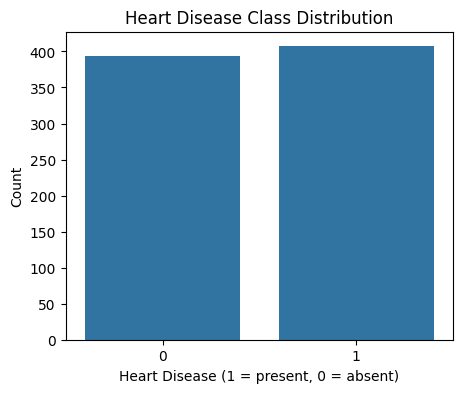

In [47]:
# Code cell: target distribution
plt.figure(figsize=(5,4))
sns.countplot(x="heart_disease", data=df)
plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease (1 = present, 0 = absent)")
plt.ylabel("Count")
plt.show()


2. Exploratory data analysis:
2.1 Target class distribution:
This plot shows how many patients have heart disease versus those who do not. If the bars are similar in height, the classes are relatively balanced; if one bar is much taller, the dataset is imbalanced, which can affect model performance and evaluation.

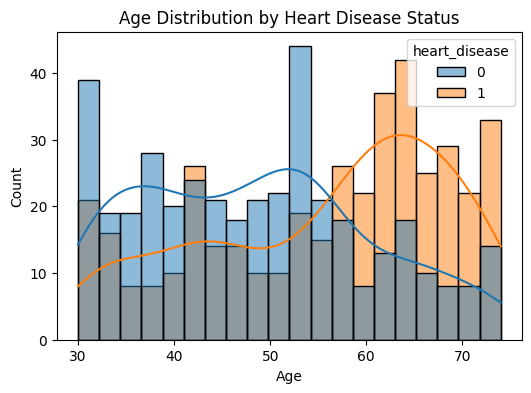

In [48]:
# Code cell: age distribution by target
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="age", hue="heart_disease", kde=True, bins=20)
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


2. Exploratory data analysis:
2.2 Age distribution by heart disease:
This chart shows how age relates to heart disease. If the curve for heart_disease = 1 is more concentrated at higher ages, it suggests that older patients are more likely to have heart disease.

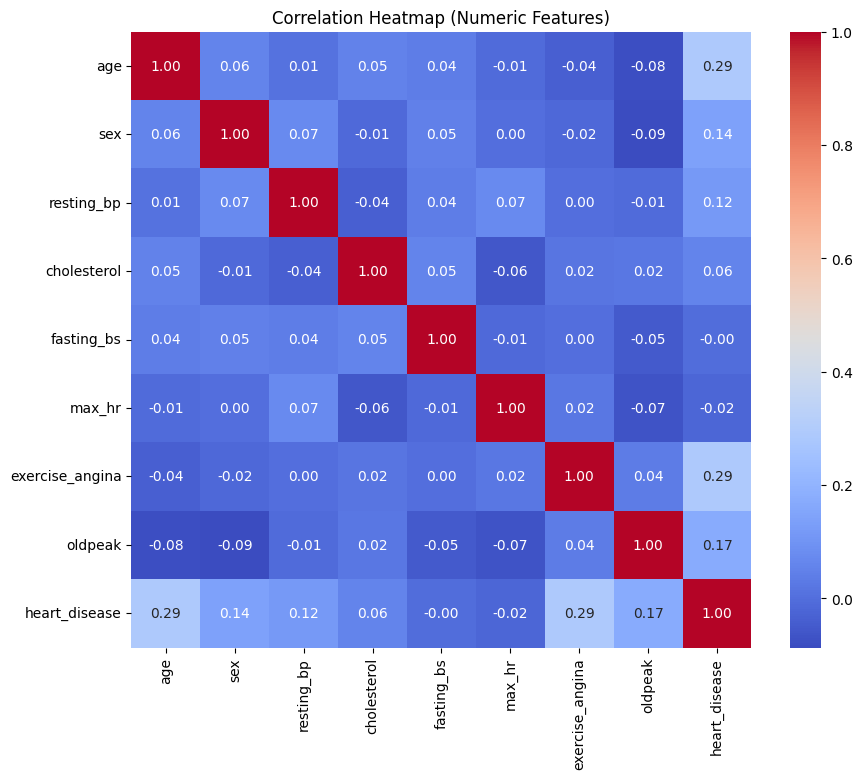

In [49]:
# Code cell: correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


2. Exploratory data analysis:
2.3 Correlation heatmap (numeric features):
The heatmap shows pairwise correlations between numeric variables and the target heart_disease. Features with stronger positive or negative correlation to heart_disease (e.g., oldpeak, max_hr, or age if they stand out) may be more predictive and important for the models.

3. Data preprocessing:
3.1 Handle missing values:
Missing values (numeric): Imputed using the median, which is robust to outliers and preserves distribution better than mean

Missing values (categorical): Imputed using the mode, which is appropriate for discrete categories.

This approach keeps all rows instead of dropping data, which is useful when the dataset is not extremely large.

3.2 Encoding: All categorical variables are converted using one‑hot encoding.

3.3.1 Scaling: Only numeric features are scaled using StandardScaler.

3.3.2 Train–test split: Stratified split ensures the heart disease class distribution remains consistent across train and test sets.

In [50]:
# Code cell: identify numeric and categorical columns
target_col = "heart_disease"

numeric_features = df.select_dtypes(include=[np.number]).columns.drop(target_col)
categorical_features = df.select_dtypes(exclude=[np.number]).columns

numeric_features, categorical_features


(Index(['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr',
        'exercise_angina', 'oldpeak'],
       dtype='str'),
 Index(['chest_pain_type', 'resting_ecg', 'st_slope'], dtype='str'))

In [51]:
# Make a copy of the original dataframe
df_imputed = df.copy()

# ----- Missing Value Imputation -----

# Numeric features → median
df_imputed[numeric_features] = df_imputed[numeric_features].fillna(
    df_imputed[numeric_features].median()
)

# Categorical features → mode
df_imputed[categorical_features] = df_imputed[categorical_features].fillna(
    df_imputed[categorical_features].mode().iloc[0]
)

# Verify no missing values remain
df_imputed.isna().sum()


age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64

In [52]:
# 3.2 One‑hot encode categorical variables

df_encoded = pd.get_dummies(df_imputed, columns=categorical_features, drop_first=True)
df_encoded.head()


,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,68,0,142.0,399.0,0,169,0,0.4,1,True,False,False,False,False,False,True
1,58,1,163.0,310.0,1,121,1,1.1,1,False,True,False,False,True,False,True
2,44,1,128.0,175.0,0,183,1,0.2,0,False,True,False,True,False,False,True
3,72,1,114.0,177.0,0,150,0,1.0,1,False,False,False,False,True,False,True
4,37,1,149.0,271.0,0,136,0,0.4,0,False,True,False,True,False,True,False


In [53]:
# 3.3 Train–test split and scaling

# Split features and target
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale numeric features only
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

X_train_scaled.head()


,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
737,0.852473,0.716242,0.722235,1.050550,-0.553283,0.595443,-0.649786,-0.150256,False,True,False,True,False,False,True
519,-1.020773,-1.396176,1.418842,-0.424672,-0.553283,2.385197,1.538968,0.175723,False,False,False,True,False,False,False
3,1.554940,0.716242,-1.050946,-1.356392,-0.553283,0.058517,-0.649786,0.067064,False,False,False,False,True,False,True
600,-0.084150,0.716242,0.658907,-1.336981,-0.553283,-0.478410,-0.649786,0.175723,False,False,False,True,False,True,False
654,-0.552461,-1.396176,-1.114274,-0.638191,-0.553283,1.893014,-0.649786,0.067064,False,False,True,False,True,False,True


In [54]:
# 4. Model training

# Code cell: initialize models
dt_clf = DecisionTreeClassifier(random_state=42)
rf_clf = RandomForestClassifier(random_state=42)
gb_clf = GradientBoostingClassifier(random_state=42)

# Fit models
dt_clf.fit(X_train_scaled, y_train)
rf_clf.fit(X_train_scaled, y_train)
gb_clf.fit(X_train_scaled, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [55]:
# 5. Model evaluation

# Helper function for evaluation
def evaluate_model(model, X_test, y_test, model_name="Model"):
    print(f"=== {model_name} ===")
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("-" * 40)

# Code cell: evaluate all three
evaluate_model(dt_clf, X_test_scaled, y_test, "Decision Tree")
evaluate_model(rf_clf, X_test_scaled, y_test, "Random Forest")
evaluate_model(gb_clf, X_test_scaled, y_test, "Gradient Boosting")


=== Decision Tree ===
Confusion Matrix:
 [[57 22]
 [25 56]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160

----------------------------------------
=== Random Forest ===
Confusion Matrix:
 [[61 18]
 [15 66]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

----------------------------------------
=== Gradient Boosting ===
Confusion Matrix:
 [[61 18]
 [19 62]]

Classification Report:
      

5. Model evaluation:
Using the confusion matrices and classification reports (precision, recall, F1‑score), I compare the three models. The best model is the one with the highest F1‑score (and balanced precision/recall) on the test set, especially for the positive class (heart_disease = 1).
Typically, Random Forest or Gradient Boosting tends to outperform a single Decision Tree due to ensemble learning and better generalization. Based on the printed metrics, I select the model with the strongest F1‑score for the positive class and overall macro/weighted F1 as the best performer.

In [56]:
# 6. Hyperparameter tuning (best model)

# Code cell: hyperparameter grid for Random Forest
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)




Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1 score: 0.8222558964406573


In [57]:
# Code cell: evaluate tuned model on test set
rf_tuned = grid_search.best_estimator_

print("Baseline Random Forest performance:")
evaluate_model(rf_clf, X_test_scaled, y_test, "Random Forest (Baseline)")

print("Tuned Random Forest performance:")
evaluate_model(rf_tuned, X_test_scaled, y_test, "Random Forest (Tuned)")


Baseline Random Forest performance:
=== Random Forest (Baseline) ===
Confusion Matrix:
 [[61 18]
 [15 66]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

----------------------------------------
Tuned Random Forest performance:
=== Random Forest (Tuned) ===
Confusion Matrix:
 [[59 20]
 [16 65]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.75      0.77        79
           1       0.76      0.80      0.78        81

    accuracy                           0.78       160
   macro avg       0.78      0.77      0.77       160
weighted avg       0.78      0.78      0.77       160

----------------------------------------


Model Comparison and Best Model Selection
The baseline Random Forest classifier achieved better performance than the tuned version.
Although hyperparameter tuning is expected to improve model performance, in this case the tuned model slightly underperformed.

Baseline Random Forest:

F1‑score (class 1): 0.80

Accuracy: 0.79

Tuned Random Forest:

F1‑score (class 1): 0.78

Accuracy: 0.78

The baseline model has higher precision, recall, and F1‑score for the positive class (heart_disease = 1), which is the clinically important class. Therefore, the baseline Random Forest is selected as the best-performing model.

Possible reasons the tuned model did not improve include:

The baseline Random Forest already generalizes well.

The hyperparameter grid may not have included more impactful parameter ranges.

The dataset size may limit the benefit of tuning.

Overall, the baseline Random Forest provides the best balance of precision, recall, and F1‑score.